# The Power of Jupyter Notebook
## A Comprehensive Demonstration

This notebook demonstrates the versatility of Jupyter Notebooks for:
- Mathematical equations with LaTeX
- Data visualization
- Statistical analysis
- Interactive plots

## 1. Mathematical Equations with LaTeX

Jupyter supports inline math $E = mc^2$ and displayed equations:

**Gaussian Distribution:**
$$ f(x|\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}} $$

**Fourier Transform:**
$$ \hat{f}(\xi) = \int_{-\infty}^{\infty} f(x) e^{-2\pi i x \xi} dx $$

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import HTML

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Basic Data Visualization

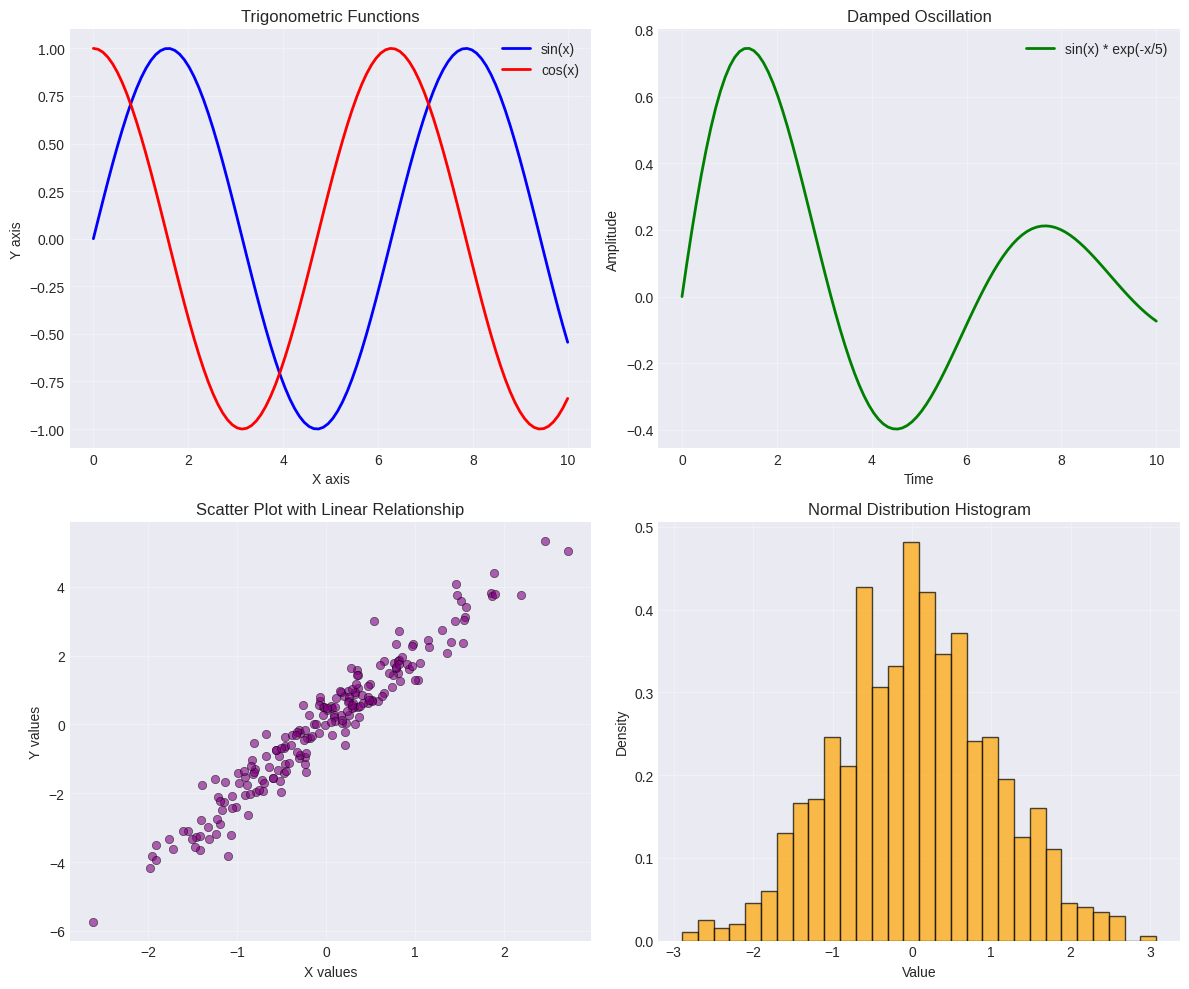

In [12]:
# Generate sample data
np.random.seed(42)
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.exp(-x/5)

# Create multiple plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Sine and Cosine
axes[0, 0].plot(x, y1, 'b-', label='sin(x)', linewidth=2)
axes[0, 0].plot(x, y2, 'r-', label='cos(x)', linewidth=2)
axes[0, 0].set_title('Trigonometric Functions')
axes[0, 0].set_xlabel('X axis')
axes[0, 0].set_ylabel('Y axis')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Damped Oscillation
axes[0, 1].plot(x, y3, 'g-', label='sin(x) * exp(-x/5)', linewidth=2)
axes[0, 1].set_title('Damped Oscillation')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Scatter plot with noise
x_scatter = np.random.randn(200)
y_scatter = 2*x_scatter + np.random.randn(200)*0.5
axes[1, 0].scatter(x_scatter, y_scatter, alpha=0.6, c='purple', edgecolors='black', linewidth=0.5)
axes[1, 0].set_title('Scatter Plot with Linear Relationship')
axes[1, 0].set_xlabel('X values')
axes[1, 0].set_ylabel('Y values')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram
data_normal = np.random.normal(0, 1, 1000)
axes[1, 1].hist(data_normal, bins=30, density=True, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].set_title('Normal Distribution Histogram')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Density')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Advanced Statistical Visualization

/tmp/ipykernel_78742/2525209043.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_stats, x='Category', y='Value', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_78742/2525209043.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_stats, x='Category', y='Value', ax=axes[0, 1], palette='Set3')


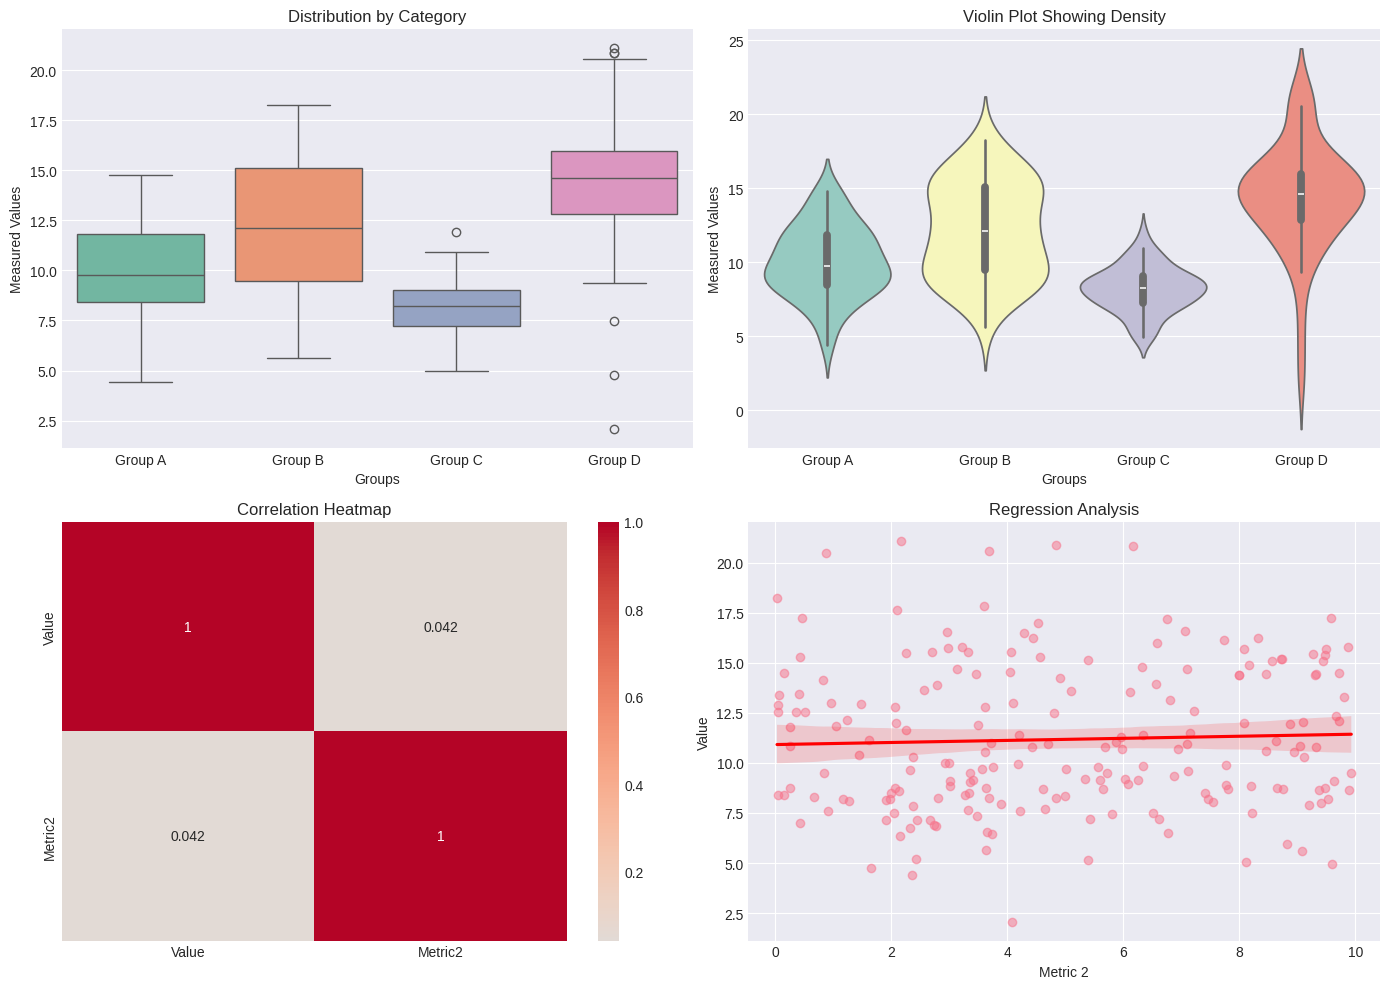

In [13]:
# Create a dataset for statistical visualization
np.random.seed(123)
categories = ['Group A', 'Group B', 'Group C', 'Group D']
data_stats = pd.DataFrame({
    'Category': np.repeat(categories, 50),
    'Value': np.concatenate([
        np.random.normal(10, 2, 50),
        np.random.normal(12, 3, 50),
        np.random.normal(8, 1.5, 50),
        np.random.normal(15, 4, 50)
    ]),
    'Metric2': np.random.uniform(0, 10, 200)
})

# Create advanced statistical plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box plot
sns.boxplot(data=data_stats, x='Category', y='Value', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribution by Category')
axes[0, 0].set_xlabel('Groups')
axes[0, 0].set_ylabel('Measured Values')

# Violin plot
sns.violinplot(data=data_stats, x='Category', y='Value', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Violin Plot Showing Density')
axes[0, 1].set_xlabel('Groups')
axes[0, 1].set_ylabel('Measured Values')

# Heatmap (correlation matrix)
corr_matrix = np.corrcoef([data_stats['Value'], data_stats['Metric2']])
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            xticklabels=['Value', 'Metric2'], yticklabels=['Value', 'Metric2'],
            ax=axes[1, 0])
axes[1, 0].set_title('Correlation Heatmap')

# Pair plot alternative (scatter with regression)
sns.regplot(data=data_stats, x='Metric2', y='Value', ax=axes[1, 1],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1, 1].set_title('Regression Analysis')
axes[1, 1].set_xlabel('Metric 2')
axes[1, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

## 4. 3D Visualization

/tmp/ipykernel_78742/1502498303.py:8: RuntimeWarning: invalid value encountered in divide
  Z = np.sin(R) / R


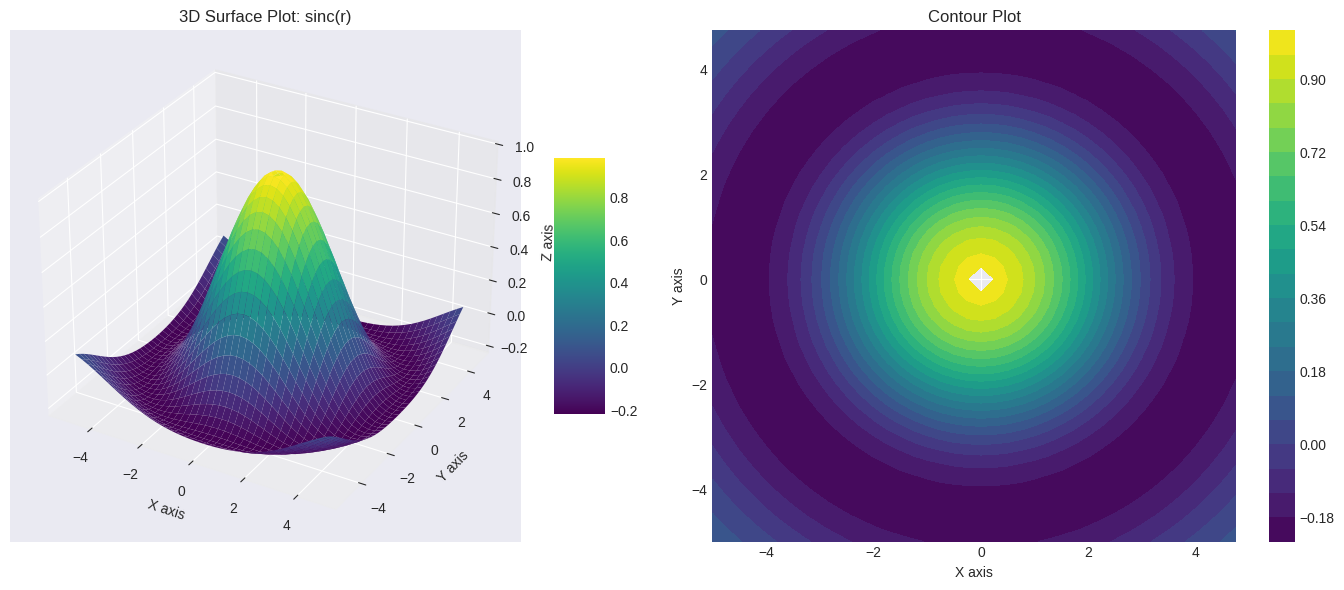

In [14]:
from mpl_toolkits.mplot3d import Axes3D

# Create 3D data
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R) / R

# Create 3D plot
fig = plt.figure(figsize=(14, 6))

# Surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax1.set_title('3D Surface Plot: sinc(r)')
ax1.set_xlabel('X axis')
ax1.set_ylabel('Y axis')
ax1.set_zlabel('Z axis')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, levels=20, cmap='viridis')
ax2.set_title('Contour Plot')
ax2.set_xlabel('X axis')
ax2.set_ylabel('Y axis')
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()

## 5. Interactive Plot with Plotly

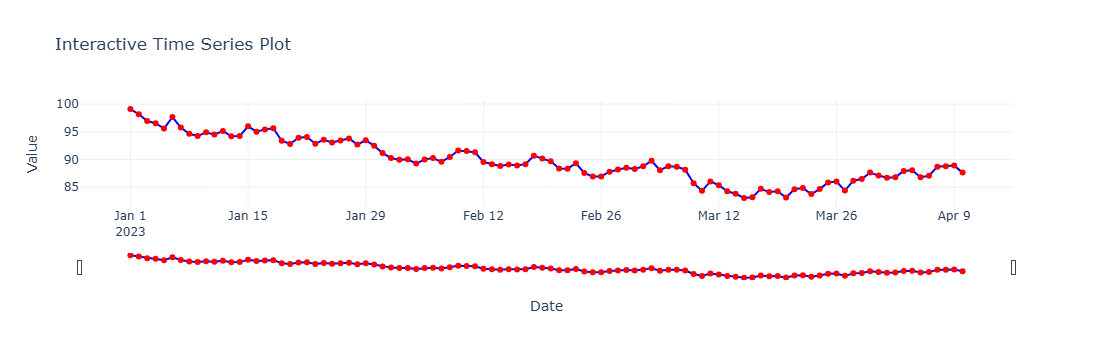

In [15]:
# Create interactive plot
# Generate time series data
dates = pd.date_range('2023-01-01', periods=100, freq='D')
values = np.cumsum(np.random.randn(100)) + 100

# Create interactive line plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=dates,
    y=values,
    mode='lines+markers',
    name='Time Series',
    line=dict(color='blue', width=2),
    marker=dict(size=6, color='red', symbol='circle')
))

fig.update_layout(
    title='Interactive Time Series Plot',
    xaxis_title='Date',
    yaxis_title='Value',
    hovermode='x unified',
    template='plotly_white'
)

# Add range slider
fig.update_xaxes(rangeslider_visible=True)

fig.show()

## 6. Statistical Analysis with Summary

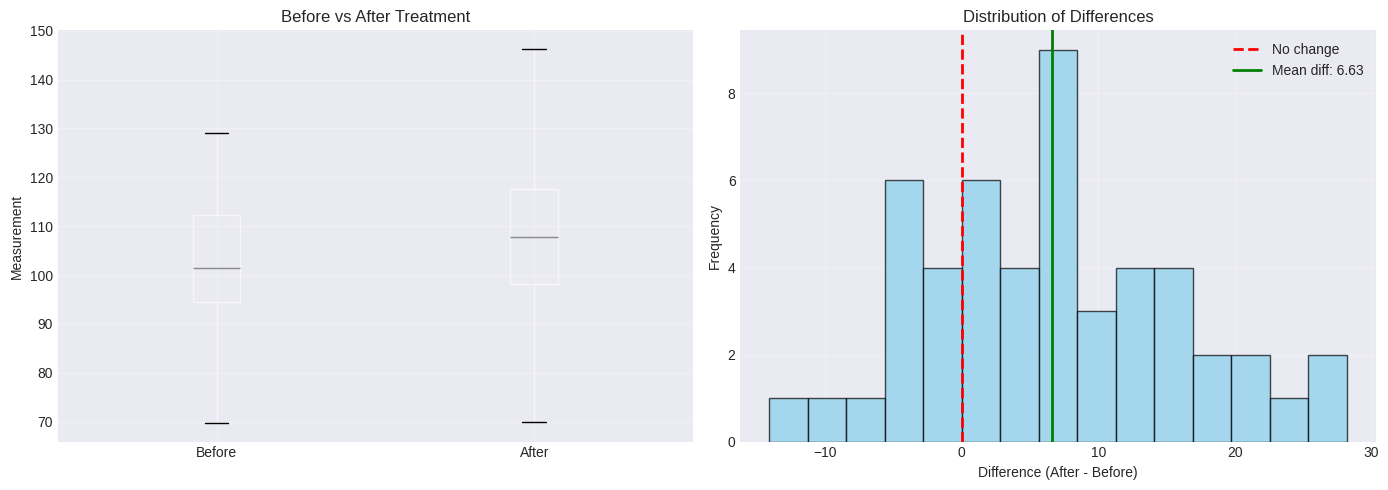

STATISTICAL ANALYSIS RESULTS
Before Treatment: Mean = 101.90, Std = 13.36
After Treatment: Mean = 108.53, Std = 18.02
Mean Difference: 6.63
Paired t-test: t = 4.8908, p-value = 0.0000
95% Confidence Interval: (3.91, 9.35)


In [ ]:
# Perform statistical analysis
np.random.seed(456)

# Generate two related datasets
before_treatment = np.random.normal(100, 15, 50)
after_treatment = before_treatment + np.random.normal(5, 10, 50)

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(after_treatment, before_treatment)

# Create comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparison
data_compare = pd.DataFrame({
    'Before': before_treatment,
    'After': after_treatment
})
data_compare.boxplot(ax=ax1)
ax1.set_title('Before vs After Treatment')
ax1.set_ylabel('Measurement')
ax1.grid(True, alpha=0.3)

# Paired difference histogram
differences = after_treatment - before_treatment
ax2.hist(differences, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
ax2.axvline(x=np.mean(differences), color='green', linestyle='-', linewidth=2,
            label=f'Mean diff: {np.mean(differences):.2f}')
ax2.set_title('Distribution of Differences')
ax2.set_xlabel('Difference (After - Before)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistical results
print("="*50)
print("STATISTICAL ANALYSIS RESULTS")
print("="*50)
print(f"Before Treatment: Mean = {np.mean(before_treatment):.2f}, Std = {np.std(before_treatment):.2f}")
print(f"After Treatment: Mean = {np.mean(after_treatment):.2f}, Std = {np.std(after_treatment):.2f}")
print(f"Mean Difference: {np.mean(differences):.2f}")
print(f"Paired t-test: t = {t_stat:.4f}, p-value = {p_value:.4f}")

# Fix: Calculate confidence interval properly
ci_lower, ci_upper = stats.t.interval(0.95, len(differences)-1,
                                      loc=np.mean(differences),
                                      scale=stats.sem(differences))
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

## 7. Displaying DataFrames and Tables

In [19]:
# Create a comprehensive dataset
np.random.seed(789)
n_samples = 20

df_demo = pd.DataFrame({
    'ID': range(1, n_samples + 1),
    'Age': np.random.randint(20, 60, n_samples),
    'Salary': np.random.normal(50000, 15000, n_samples).round(-2),
    'Experience': np.random.randint(0, 30, n_samples),
    'Score': np.random.uniform(60, 100, n_samples).round(1),
    'Department': np.random.choice(['Engineering', 'Marketing', 'Sales', 'HR'], n_samples),
    'Remote': np.random.choice([True, False], n_samples, p=[0.6, 0.4])
})

# Display the dataframe with styling - 使用括号进行换行，而不是 \n
styled_df = (df_demo.style
             .background_gradient(cmap='Blues', subset=['Score'])
             .bar(subset=['Salary'], color='#5fba7d')
             .format({'Salary': '${:,.0f}', 'Score': '{:.1f}%'})
             .set_caption('Employee Dataset Overview'))

# 显示样式化后的数据框
styled_df

# Display summary statistics
print("\nDataset Summary Statistics:")
print(df_demo.describe())

print("\nDepartment Distribution:")
print(df_demo['Department'].value_counts())


Dataset Summary Statistics:
             ID        Age        Salary  Experience      Score
count  20.00000  20.000000     20.000000   20.000000  20.000000
mean   10.50000  37.750000  46760.000000   14.500000  81.075000
std     5.91608  10.769719  15849.801593    8.629814  10.792291
min     1.00000  21.000000  22500.000000    1.000000  61.100000
25%     5.75000  31.000000  32050.000000    8.250000  71.325000
50%    10.50000  37.000000  45550.000000   15.500000  82.300000
75%    15.25000  46.250000  60825.000000   21.750000  90.675000
max    20.00000  55.000000  71800.000000   27.000000  97.200000

Department Distribution:
HR             7
Marketing      6
Engineering    4
Sales          3
Name: Department, dtype: int64


## 8. Advanced: Custom Visualization with Multiple Axes

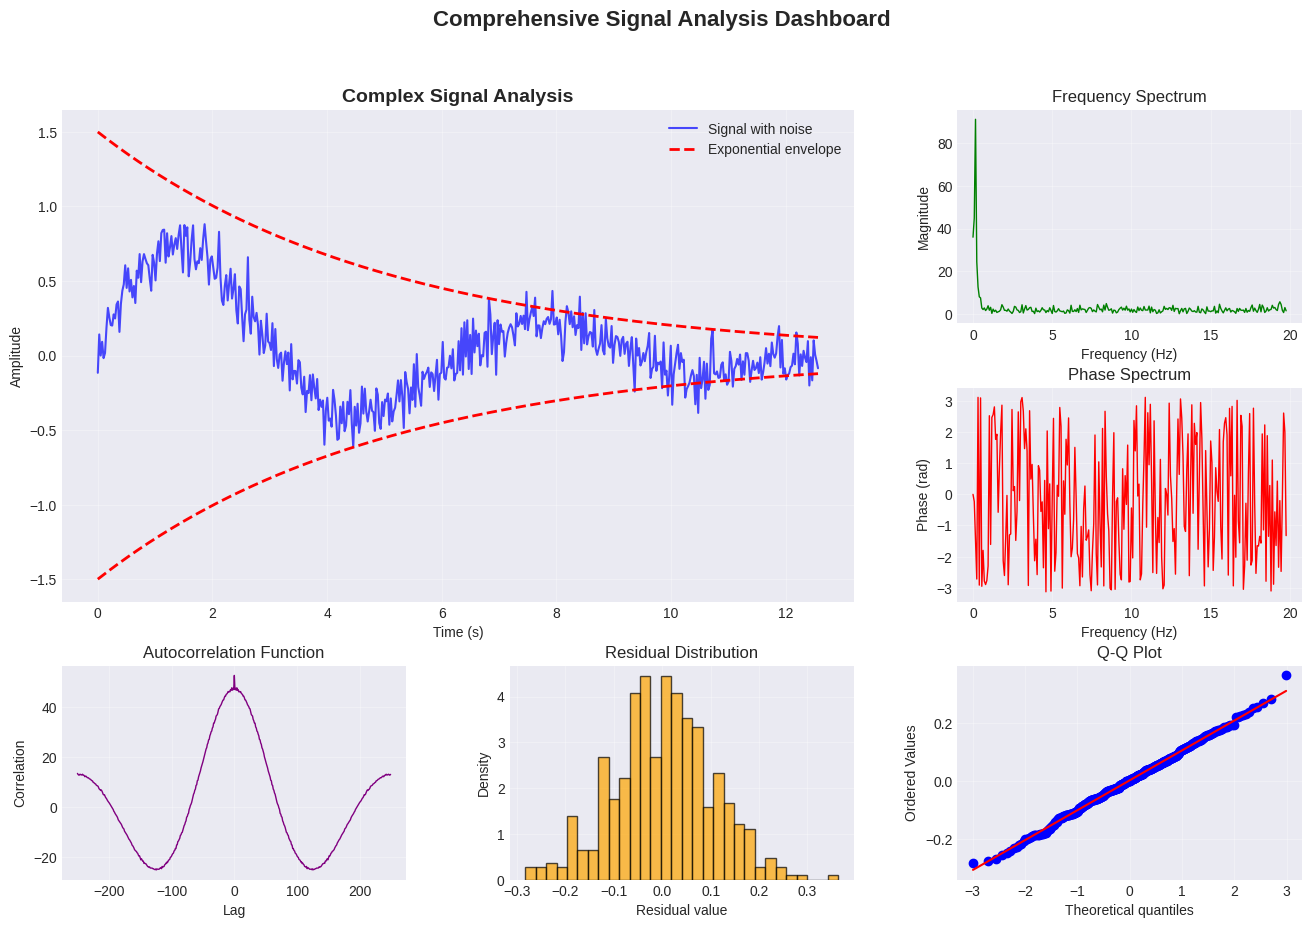

In [20]:
# Create a complex visualization combining multiple elements
fig = plt.figure(figsize=(16, 10))

# Define grid for subplots
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Main large plot
ax_main = fig.add_subplot(gs[0:2, 0:2])

# Generate complex data
t = np.linspace(0, 4*np.pi, 500)
y_main = np.sin(t) * np.exp(-t/5) + 0.1*np.random.randn(len(t))
y_trend = np.exp(-t/5) * 1.5

ax_main.plot(t, y_main, 'b-', alpha=0.7, label='Signal with noise')
ax_main.plot(t, y_trend, 'r--', linewidth=2, label='Exponential envelope')
ax_main.plot(t, -y_trend, 'r--', linewidth=2)
ax_main.set_title('Complex Signal Analysis', fontsize=14, fontweight='bold')
ax_main.set_xlabel('Time (s)')
ax_main.set_ylabel('Amplitude')
ax_main.legend(loc='upper right')
ax_main.grid(True, alpha=0.3)

# Fourier Transform magnitude
ax_fft = fig.add_subplot(gs[0, 2])
fft_mag = np.abs(np.fft.fft(y_main))[:250]
freqs = np.fft.fftfreq(len(t), t[1]-t[0])[:250]
ax_fft.plot(freqs, fft_mag, 'g-', linewidth=1)
ax_fft.set_title('Frequency Spectrum')
ax_fft.set_xlabel('Frequency (Hz)')
ax_fft.set_ylabel('Magnitude')
ax_fft.grid(True, alpha=0.3)

# Phase plot
ax_phase = fig.add_subplot(gs[1, 2])
phase = np.angle(np.fft.fft(y_main))[:250]
ax_phase.plot(freqs, phase, 'r-', linewidth=1)
ax_phase.set_title('Phase Spectrum')
ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.set_ylabel('Phase (rad)')
ax_phase.grid(True, alpha=0.3)

# Autocorrelation
ax_acf = fig.add_subplot(gs[2, 0])
acf = np.correlate(y_main, y_main, mode='same')
lags = np.arange(-len(y_main)//2, len(y_main)//2)
ax_acf.plot(lags, acf, 'purple', linewidth=1)
ax_acf.set_title('Autocorrelation Function')
ax_acf.set_xlabel('Lag')
ax_acf.set_ylabel('Correlation')
ax_acf.grid(True, alpha=0.3)

# Distribution of residuals
ax_hist = fig.add_subplot(gs[2, 1])
residuals = y_main - np.sin(t) * np.exp(-t/5)
ax_hist.hist(residuals, bins=30, density=True, alpha=0.7, color='orange', edgecolor='black')
ax_hist.set_title('Residual Distribution')
ax_hist.set_xlabel('Residual value')
ax_hist.set_ylabel('Density')
ax_hist.grid(True, alpha=0.3)

# Q-Q plot
ax_qq = fig.add_subplot(gs[2, 2])
stats.probplot(residuals, dist="norm", plot=ax_qq)
ax_qq.set_title('Q-Q Plot')
ax_qq.grid(True, alpha=0.3)

plt.suptitle('Comprehensive Signal Analysis Dashboard', fontsize=16, fontweight='bold')
plt.show()

## 9. Markdown Features

### Text Formatting
- **Bold text** for emphasis
- *Italic text* for citations
- `Code snippets` for inline code
- ~~Strikethrough~~ for corrections

### Lists
1. First ordered list item
2. Another item
   - Unordered sub-item
   - Another sub-item
3. Third item

### Tables
| Feature | Description | Support |
|---------|-------------|---------|
| LaTeX | Mathematical equations | ✅ |
| Plots | Data visualization | ✅ |
| Interactive | Dynamic content | ✅ |
| Markdown | Rich text formatting | ✅ |

### Code Blocks with Syntax Highlighting
```python
def analyze_data(data):
    """
    Perform comprehensive data analysis
    """
    mean_val = np.mean(data)
    std_val = np.std(data)
    return {
        'mean': mean_val,
        'std': std_val,
        'n_samples': len(data)
    }
```

### Blockquotes
> Jupyter notebooks are powerful tools for data science,
> combining code, visualization, and documentation in one place.
> — Data Science Community

### Horizontal Rule
---

## 10. Summary

This notebook has demonstrated key Jupyter capabilities:

✅ **Rich Text Formatting** with Markdown and HTML
✅ **Mathematical Equations** with LaTeX
✅ **Static Visualizations** with Matplotlib and Seaborn
✅ **Interactive Plots** with Plotly
✅ **3D Graphics**
✅ **Statistical Analysis** with SciPy
✅ **DataFrame Display** with Pandas
✅ **Custom Layouts** with GridSpec

These features make Jupyter Notebooks an ideal environment for:
- Data exploration and analysis
- Scientific research and reproducibility
- Teaching and learning
- Reporting and presentation
- Collaborative projects